# **Netflix Dataset EDA & Visualization**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
df = pd.read_csv('/content/drive/MyDrive/netflix_titles.csv')
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


### **Data Overview**

In [5]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [6]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [7]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [8]:
df.shape

(8807, 12)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [10]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [11]:
df.duplicated('show_id').sum()

np.int64(0)

#### **Data Cleaning**

In [13]:
df.columns = df.columns.str.strip()

In [14]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [15]:
df['director'] = df['director'].replace('Rajiv Chilaka','Rajiv Shukla')

In [16]:
# filling missing values in columns (director,cast,country) with "Unknown"
df[["director","cast","country"]] = df[["director","cast","country"]].fillna("Unkown")

In [17]:
df["date_added"] = df["date_added"].fillna(df["date_added"].mode()[0])

In [18]:
df["rating"] = df["rating"].fillna(df["rating"].mode()[0])

In [19]:
df["duration"] = df["duration"].fillna(df["duration"].mode()[0])

In [22]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


- Now Data is cleaned and ready for analysis

# **EDA & Visualization**

- Distribution type

In [23]:
type_dist = df['type'].value_counts()
type_dist

,count
type,
Movie,6131
TV Show,2676


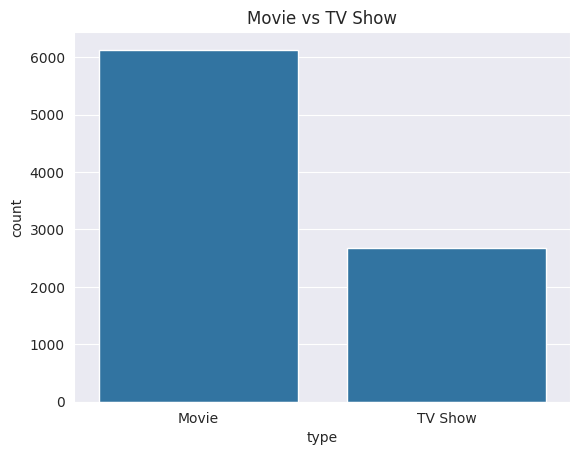

In [26]:
sns.set_style('darkgrid')
sns.countplot(x='type',data=df)
plt.title('Movie vs TV Show')
plt.show()

- Insight movies are more then TV show
  - Movies Count (6131)
  - TV Show (2676)

- Release Year Distribution

In [27]:
releases = df['release_year'].value_counts()
releases

,count
release_year,
2018,1147
2017,1032
2019,1030
2020,953
2016,902
...,...
1961,1
1925,1
1959,1


### Alternative: Histogram using `sns.histplot`

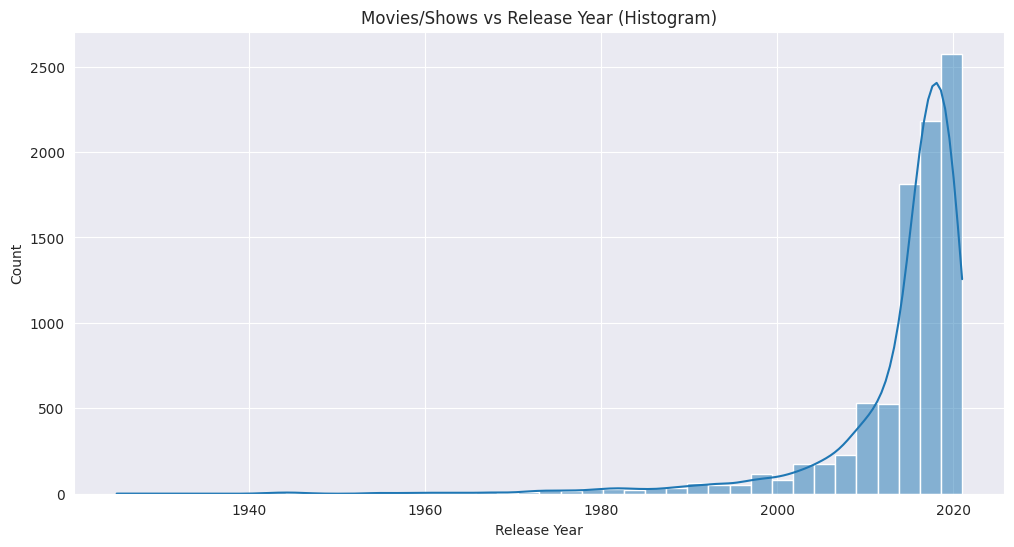

In [29]:
plt.figure(figsize=(12, 6))
sns.histplot(x="release_year", data=df, bins=40, kde=True)
plt.title("Movies/Shows vs Release Year (Histogram)")
plt.xlabel("Release Year")
plt.ylabel("Count")
plt.show()

### Alternative: Kernel Density Estimate plot using `sns.kdeplot`

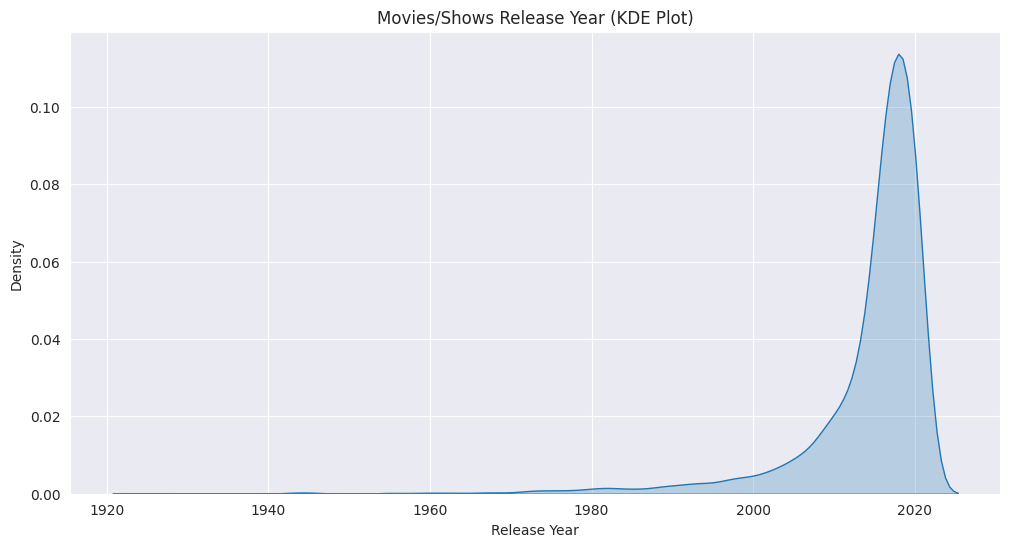

In [30]:
plt.figure(figsize=(12, 6))
sns.kdeplot(x="release_year", data=df, fill=True)
plt.title("Movies/Shows Release Year (KDE Plot)")
plt.xlabel("Release Year")
plt.ylabel("Density")
plt.show()

- Most released years are between 2015-2020 while before 2000 released rate is lowest.

In [31]:
rating = df['rating'].value_counts()
rating

,count
rating,
TV-MA,3211
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


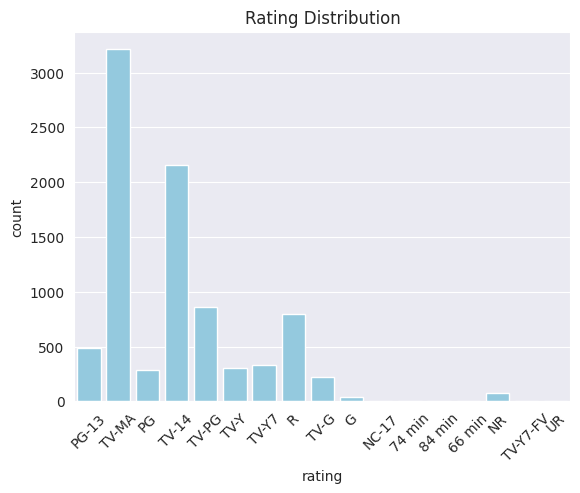

In [37]:
sns.countplot(x="rating",data=df,color="skyBlue")
plt.tick_params(axis="x",rotation=45)
plt.title("Rating Distribution")
plt.show()

- TV-MA has the highest the rating (3211) and the second most common is TV-14 (2160).

- **Do Movies and TV Shows have different Ratings**

In [39]:
df[['type','rating']].value_counts()

type     rating  
Movie    TV-MA       2064
         TV-14       1427
TV Show  TV-MA       1147
Movie    R            797
TV Show  TV-14        733
Movie    TV-PG        540
         PG-13        490
TV Show  TV-PG        323
Movie    PG           287
TV Show  TV-Y7        195
         TV-Y         176
Movie    TV-Y7        139
         TV-Y         131
         TV-G         126
TV Show  TV-G          94
Movie    NR            75
         G             41
         TV-Y7-FV       5
TV Show  NR             5
Movie    UR             3
         NC-17          3
TV Show  R              2
Movie    84 min         1
         74 min         1
         66 min         1
TV Show  TV-Y7-FV       1
Name: count, dtype: int64

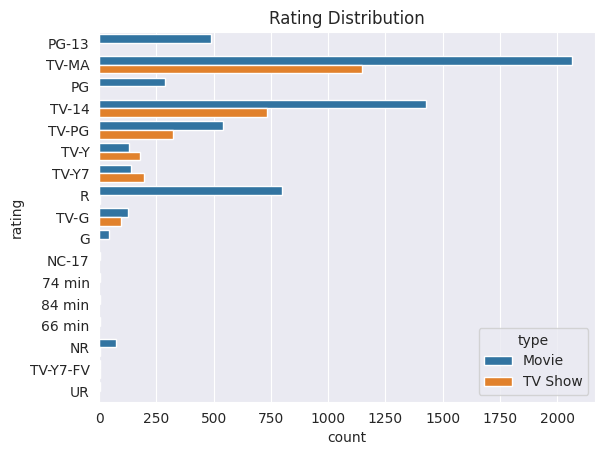

In [40]:
sns.countplot(y='rating',data=df,hue='type')
plt.title('Rating Distribution')
plt.show()

- Movies dominates most rating categories like TV MA and TV 14 which show adult content.

- **Which Counties produces more Movie/Tv Show.**

In [41]:
country = df['country'].value_counts()
country

,count
country,
United States,2818
India,972
Unkown,831
United Kingdom,419
Japan,245
...,...
"Germany, Canada, United States",1
"Denmark, United Kingdom, South Africa, Sweden, Belgium",1
"Serbia, South Korea, Slovenia",1


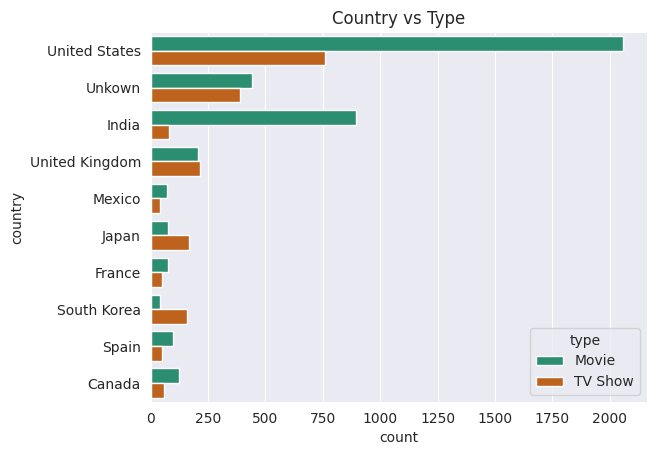

In [46]:
top10 = df["country"].value_counts().head(10).index
top_df = df[df["country"].isin(top10)]
sns.countplot(data=top_df,y="country",hue="type",palette="Dark2")
plt.title("Country vs Type")
plt.show()

- United States produces the highest number of content and India is second in terms of producing highest no of movies.
- Then unknown countries (not mentioned in record) shows significant record in terms of producing movies and TV shows.

- **Which year release more movies and TV Show.**

In [48]:
# keeping top ten release years
top_years = df["release_year"].value_counts().head(10).index
years_df = df[df["release_year"].isin(top_years)]

In [49]:
df[["type","release_year"]].value_counts()

type     release_year
Movie    2017            767
         2018            767
         2016            658
         2019            633
         2020            517
                        ... 
TV Show  1946              1
         1977              1
         1974              1
         1967              1
         1991              1
Name: count, Length: 119, dtype: int64

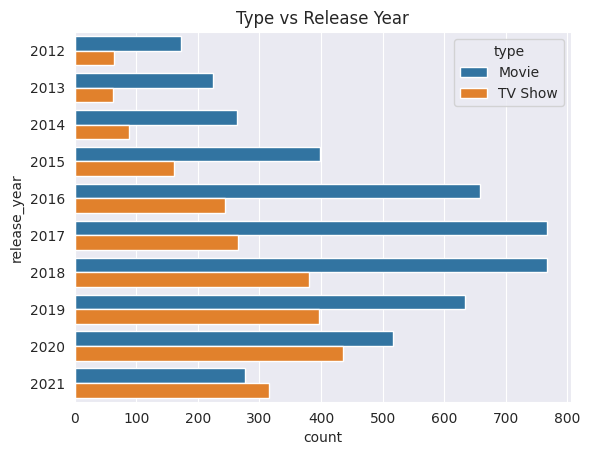

In [50]:
sns.countplot(data=years_df,y="release_year",hue="type")
plt.title("Type vs Release Year")
plt.show()

- Years 2017 and 2018 has released most number of movies each (767) while 2020 released most number of TV Shows.

- **Duration distribution (Most Common Duration)**

In [53]:
top_duration = df['duration'].value_counts().head(10).index
duration_df = df[df["duration"].isin(top_duration)]

In [54]:
df['duration'].value_counts().head(10)

,count
duration,
1 Season,1796
2 Seasons,425
3 Seasons,199
90 min,152
97 min,146
94 min,146
93 min,146
91 min,144
95 min,137


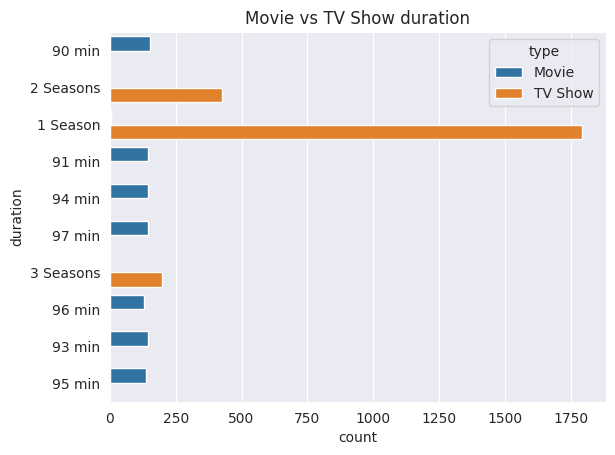

In [55]:
sns.countplot(y="duration",data=duration_df,hue="type")
plt.title("Movie vs TV Show duration")
plt.show()

- Most Movies duration lies between 90 to 97 minute while most tv shows ended in first season(1796).

- **Top Countries producing content**

In [56]:
countries = df["country"].value_counts().head(10)

In [57]:
countries

,count
country,
United States,2818
India,972
Unkown,831
United Kingdom,419
Japan,245
South Korea,199
Canada,181
Spain,145
France,124


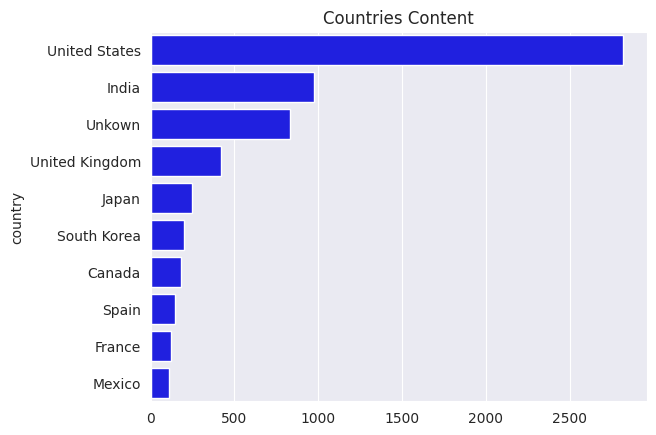

In [60]:
sns.barplot(x=countries.values,y=countries.index,color="blue")
plt.title("Countries Content")
plt.show()

- United States tops by producing most content followed by India and some countries are not known yet they also ranks 3rd.

**Conclusion**

The analysis reveals that Netflix's content library is predominantly composed of movies, significantly outnumbering TV shows. Most of the titles were released between 2015 and 2020, reflecting the platform's strong emphasis on expanding its catalog during this period. The most common content ratings are TV-MA and TV-14, indicating that Netflix primarily targets mature and teenage audiences with a diverse range of entertainment.

Geographically, the United States is the largest contributor to Netflix's content library, followed by India, highlighting the platform's strong presence in these major entertainment markets. Across nearly all rating categories, movies remain the dominant content type, while the majority of TV shows consist of only a single season, suggesting a preference for limited-series formats or recently introduced shows.

Overall, the dataset demonstrates Netflix's strategic focus on movie-centric content, recent releases, and audience-driven programming. These trends reflect the platform's commitment to offering a diverse and contemporary catalog that caters to the viewing preferences of a global audience.
